# Summary of LOCO Random Forest Results (This Pipeline)

This notebook summarizes results from **Leave-One-Cohort-Out (LOCO) cross-validation** with **3 runs per fold** for consensus-based feature selection.

**Data Sources:**
- `results_taxa/loco_results_taxa.csv`
- `results_functions/loco_results_functions.csv`
- `results_combined/loco_results_combined.csv`

**Note:** Each row in the results files represents one fold (one test cohort). Results are based on consensus features selected in >= 2 out of 3 runs per fold.

**Outputs:**
- Compact summary table (Mean + Weighted Mean AUC)
- Per-fold statistics (mean, std, min, max across folds)
- Mean AUC barplot (by data type, grouped by feature configuration)
- Weighted Mean AUC barplot
- Per-fold AUC distribution boxplots
- Per-cohort AUC barplots for taxa / functions / combined

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

RESULT_FILES = {
    'Taxa': 'results_taxa/loco_results_taxa.csv',
    'Functions': 'results_functions/loco_results_functions.csv',
    'Combined': 'results_combined/loco_results_combined.csv',
}

# Columns can differ slightly across pipelines; handle common synonyms.
COL_SYNONYMS = {
    'feature_only': ['All Features', 'All Taxa', 'All Functions'],
    'synthetic_only': ['Synthetic Only'],
    'combined': ['All Features + Synthetic', 'All Taxa + Synthetic', 'All Functions + Synthetic'],
}

def _pick_first_existing(df_cols, candidates):
    for c in candidates:
        if c in df_cols:
            return c
    return None

def load_loco_results(path):
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path)
    if 'Test Cohort' not in df.columns:
        raise ValueError(f"Expected 'Test Cohort' column in {path}. Got columns: {df.columns.tolist()}")
    df = df.set_index('Test Cohort')
    return df

# Load only files that exist (for now, only TAXA)
results = {}
for mode, path in RESULT_FILES.items():
    df = load_loco_results(path)
    if df is not None:
        results[mode] = df
        print(f"{mode}: shape={df.shape}; columns={df.columns.tolist()}")
    else:
        print(f"{mode}: File not found ({path}), skipping...")

if not results:
    raise ValueError("No result files found! Please run main_code.ipynb first.")

Taxa: shape=(16, 4); columns=['N Samples', 'All Features', 'Synthetic Only', 'All Features + Synthetic']
Functions: shape=(16, 4); columns=['N Samples', 'All Features', 'Synthetic Only', 'All Features + Synthetic']
Combined: shape=(16, 4); columns=['N Samples', 'All Features', 'Synthetic Only', 'All Features + Synthetic']


In [2]:
def extract_mean_rows(df):
    if 'Mean' not in df.index or 'Weighted Mean' not in df.index:
        raise ValueError("Expected 'Mean' and 'Weighted Mean' rows in LOCO results")
    return df.loc['Mean'], df.loc['Weighted Mean']


def to_long(df, mode_label):
    feature_col = _pick_first_existing(df.columns, COL_SYNONYMS['feature_only'])
    synth_col = _pick_first_existing(df.columns, COL_SYNONYMS['synthetic_only'])
    comb_col = _pick_first_existing(df.columns, COL_SYNONYMS['combined'])

    if feature_col is None or synth_col is None or comb_col is None:
        raise ValueError(
            f"Missing expected columns for {mode_label}. Found: {df.columns.tolist()}\n"
            f"feature_only candidates={COL_SYNONYMS['feature_only']}\n"
            f"synthetic_only candidates={COL_SYNONYMS['synthetic_only']}\n"
            f"combined candidates={COL_SYNONYMS['combined']}"
        )

    melted = (
        df.reset_index()
          .rename(columns={'index': 'Test Cohort'})
          .melt(
              id_vars=['Test Cohort'],
              value_vars=[feature_col, synth_col, comb_col],
              var_name='Config',
              value_name='AUC'
          )
    )

    config_map = {
        feature_col: 'Feature Only',
        synth_col: 'Synthetic Only',
        comb_col: 'Combined',
    }
    melted['Feature Type'] = melted['Config'].map(config_map)
    melted['Mode'] = mode_label

    # Best-effort: extract N Samples for cohorts (Mean rows have NaN)
    if 'N Samples' in df.columns:
        n_samples = df['N Samples'].copy()
        melted = melted.merge(
            n_samples.rename('N Samples').reset_index().rename(columns={'Test Cohort': 'Test Cohort'}),
            on='Test Cohort',
            how='left'
        )

    return melted


# Build compact summary table (Mean + Weighted Mean)
summary_rows = []
for mode, df in results.items():
    mean_row, wmean_row = extract_mean_rows(df)

    feature_col = _pick_first_existing(df.columns, COL_SYNONYMS['feature_only'])
    synth_col = _pick_first_existing(df.columns, COL_SYNONYMS['synthetic_only'])
    comb_col = _pick_first_existing(df.columns, COL_SYNONYMS['combined'])

    for col, ft in [(feature_col, 'Feature Only'), (synth_col, 'Synthetic Only'), (comb_col, 'Combined')]:
        summary_rows.append({
            'Mode': mode,
            'Feature Type': ft,
            'Mean AUC': float(mean_row[col]),
            'Weighted Mean AUC': float(wmean_row[col]),
        })

summary_df = pd.DataFrame(summary_rows)
print("="*80)
print("PERFORMANCE SUMMARY TABLE")
print("="*80)
print(summary_df.to_string(index=False))


PERFORMANCE SUMMARY TABLE
     Mode   Feature Type  Mean AUC  Weighted Mean AUC
     Taxa   Feature Only  0.849126           0.818612
     Taxa Synthetic Only  0.836929           0.810390
     Taxa       Combined  0.836566           0.811247
Functions   Feature Only  0.678634           0.664533
Functions Synthetic Only  0.672670           0.656770
Functions       Combined  0.674858           0.660460
 Combined   Feature Only  0.821380           0.798157
 Combined Synthetic Only  0.832932           0.805021
 Combined       Combined  0.830727           0.804743


In [3]:
# Calculate per-fold statistics (excluding Mean/Weighted Mean rows)
def get_per_fold_stats(df):
    """Extract per-fold data (exclude Mean and Weighted Mean rows)"""
    # Exclude summary rows
    fold_data = df.drop(['Mean', 'Weighted Mean'], errors='ignore')
    return fold_data

# Calculate statistics across folds for each mode
print("="*80)
print("PER-FOLD STATISTICS (Across All Folds)")
print("="*80)

for mode, df in results.items():
    fold_data = get_per_fold_stats(df)
    
    feature_col = _pick_first_existing(df.columns, COL_SYNONYMS['feature_only'])
    synth_col = _pick_first_existing(df.columns, COL_SYNONYMS['synthetic_only'])
    comb_col = _pick_first_existing(df.columns, COL_SYNONYMS['combined'])
    
    if feature_col and synth_col and comb_col:
        print(f"\n{mode}:")
        print(f"  Number of folds: {len(fold_data)}")
        
        for col, label in [(feature_col, 'All Features'), 
                           (synth_col, 'Synthetic Only'), 
                           (comb_col, 'All Features + Synthetic')]:
            values = fold_data[col].dropna()
            if len(values) > 0:
                print(f"\n  {label}:")
                print(f"    Mean: {values.mean():.4f}")
                print(f"    Std:  {values.std():.4f}")
                print(f"    Min:  {values.min():.4f}")
                print(f"    Max:  {values.max():.4f}")
                print(f"    Range: {values.max() - values.min():.4f}")

PER-FOLD STATISTICS (Across All Folds)

Taxa:
  Number of folds: 14

  All Features:
    Mean: 0.8491
    Std:  0.0749
    Min:  0.7264
    Max:  0.9537
    Range: 0.2273

  Synthetic Only:
    Mean: 0.8369
    Std:  0.0664
    Min:  0.7315
    Max:  0.9316
    Range: 0.2001

  All Features + Synthetic:
    Mean: 0.8366
    Std:  0.0678
    Min:  0.7341
    Max:  0.9302
    Range: 0.1961

Functions:
  Number of folds: 14

  All Features:
    Mean: 0.6786
    Std:  0.0801
    Min:  0.5225
    Max:  0.7950
    Range: 0.2725

  Synthetic Only:
    Mean: 0.6727
    Std:  0.0744
    Min:  0.5350
    Max:  0.7963
    Range: 0.2613

  All Features + Synthetic:
    Mean: 0.6749
    Std:  0.0727
    Min:  0.5291
    Max:  0.7792
    Range: 0.2501

Combined:
  Number of folds: 14

  All Features:
    Mean: 0.8214
    Std:  0.0644
    Min:  0.7159
    Max:  0.9288
    Range: 0.2129

  Synthetic Only:
    Mean: 0.8329
    Std:  0.0639
    Min:  0.7289
    Max:  0.9330
    Range: 0.2041

  All Feat

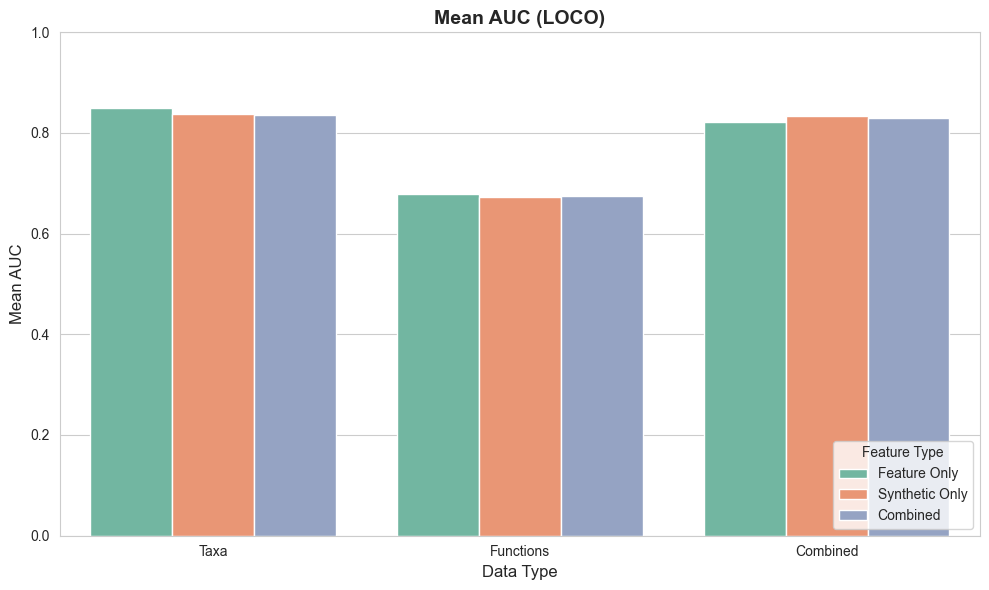

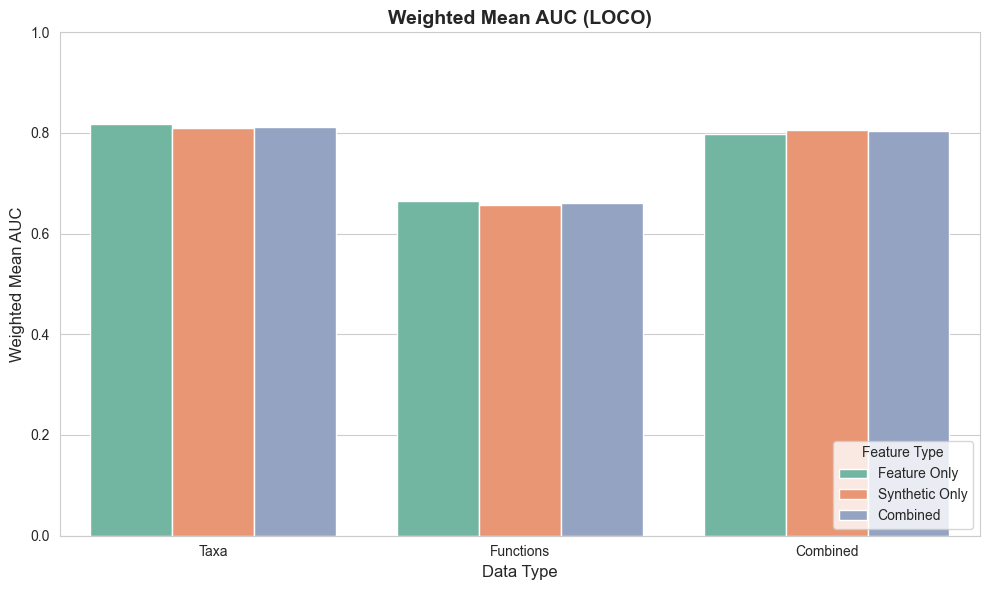

In [4]:
# Plot 1: Mean AUC grouped by mode and hue by feature type
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=summary_df, x='Mode', y='Mean AUC', hue='Feature Type', palette='Set2')
plt.title('Mean AUC (LOCO)', fontsize=14, fontweight='bold')
plt.ylabel('Mean AUC', fontsize=12)
plt.xlabel('Data Type', fontsize=12)
plt.legend(title='Feature Type', loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Plot 2: Weighted Mean AUC
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=summary_df, x='Mode', y='Weighted Mean AUC', hue='Feature Type', palette='Set2')
plt.title('Weighted Mean AUC (LOCO)', fontsize=14, fontweight='bold')
plt.ylabel('Weighted Mean AUC', fontsize=12)
plt.xlabel('Data Type', fontsize=12)
plt.legend(title='Feature Type', loc='lower right')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


/var/folders/14/cbbyp9td0gl7qft267hmvqs00000gn/T/ipykernel_6351/472768855.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[ax_idx].boxplot(plot_data, labels=labels, patch_artist=True, medianprops=dict(color="black", linewidth=1.5))
/var/folders/14/cbbyp9td0gl7qft267hmvqs00000gn/T/ipykernel_6351/472768855.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[ax_idx].boxplot(plot_data, labels=labels, patch_artist=True, medianprops=dict(color="black", linewidth=1.5))
/var/folders/14/cbbyp9td0gl7qft267hmvqs00000gn/T/ipykernel_6351/472768855.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = a

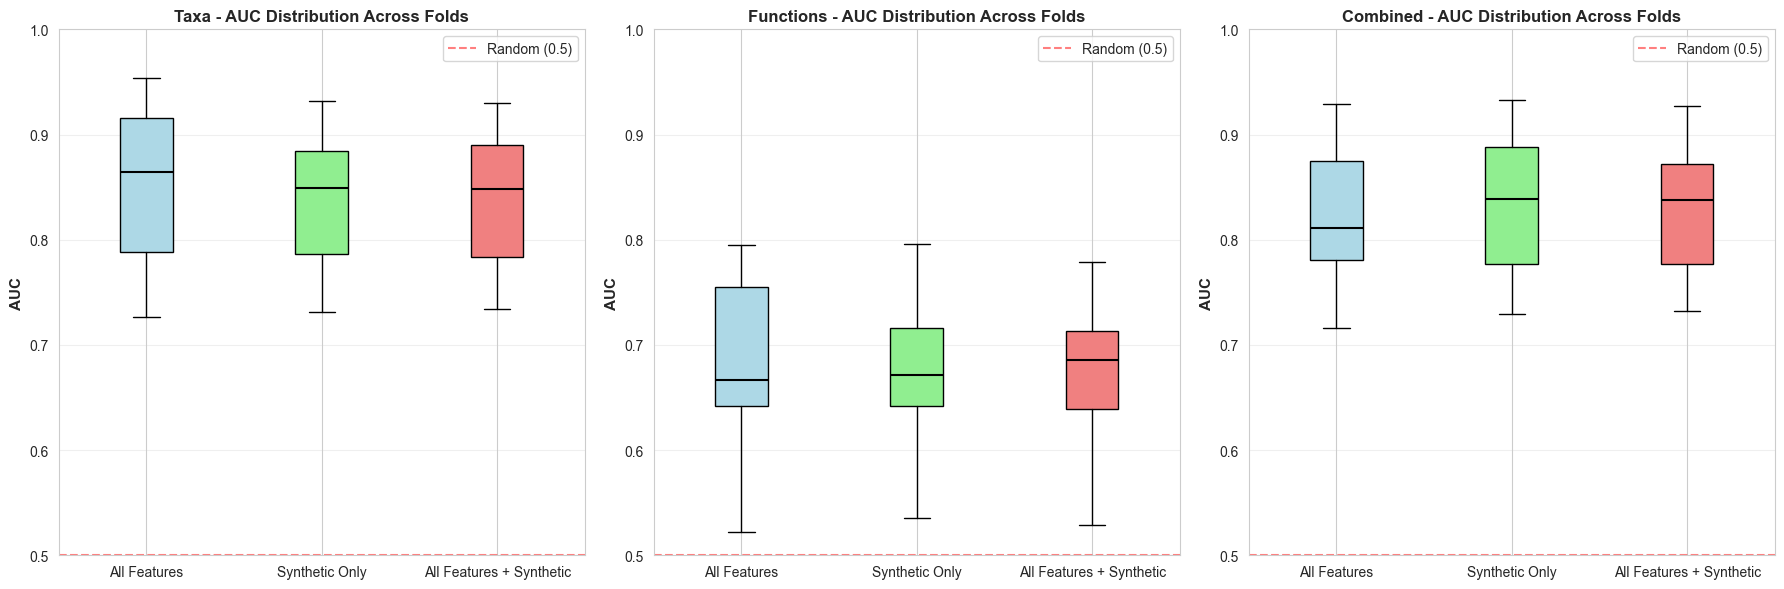


Note: Each fold represents one test cohort in LOCO cross-validation.
Results are based on consensus features selected in >= 2 out of 3 runs per fold.


In [5]:
# Per-fold performance visualization (boxplots)
# This shows the distribution of AUC across all folds (test cohorts)

fig, axes = plt.subplots(1, len(results), figsize=(6*len(results), 6))
if len(results) == 1:
    axes = [axes]

for ax_idx, (mode, df) in enumerate(results.items()):
    fold_data = get_per_fold_stats(df)
    
    feature_col = _pick_first_existing(df.columns, COL_SYNONYMS['feature_only'])
    synth_col = _pick_first_existing(df.columns, COL_SYNONYMS['synthetic_only'])
    comb_col = _pick_first_existing(df.columns, COL_SYNONYMS['combined'])
    
    if feature_col and synth_col and comb_col:
        # Prepare data for boxplot
        plot_data = []
        labels = []
        
        for col, label in [(feature_col, 'All Features'), 
                          (synth_col, 'Synthetic Only'), 
                          (comb_col, 'All Features + Synthetic')]:
            values = fold_data[col].dropna()
            if len(values) > 0:
                plot_data.append(values)
                labels.append(label)
        
        if plot_data:
            bp = axes[ax_idx].boxplot(plot_data, labels=labels, patch_artist=True, medianprops=dict(color="black", linewidth=1.5))
            
            # Color the boxes
            colors = ['lightblue', 'lightgreen', 'lightcoral']
            for patch, color in zip(bp['boxes'], colors[:len(bp['boxes'])]):
                patch.set_facecolor(color)
            
            axes[ax_idx].set_title(f'{mode} - AUC Distribution Across Folds', fontsize=12, fontweight='bold')
            axes[ax_idx].set_ylabel('AUC', fontsize=11, fontweight='bold')
            axes[ax_idx].set_ylim([0.5, 1.0])
            axes[ax_idx].grid(True, alpha=0.3, axis='y')
            axes[ax_idx].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Random (0.5)')
            axes[ax_idx].legend()

plt.tight_layout()
plt.show()

print(f"\nNote: Each fold represents one test cohort in LOCO cross-validation.")
print(f"Results are based on consensus features selected in >= 2 out of 3 runs per fold.")

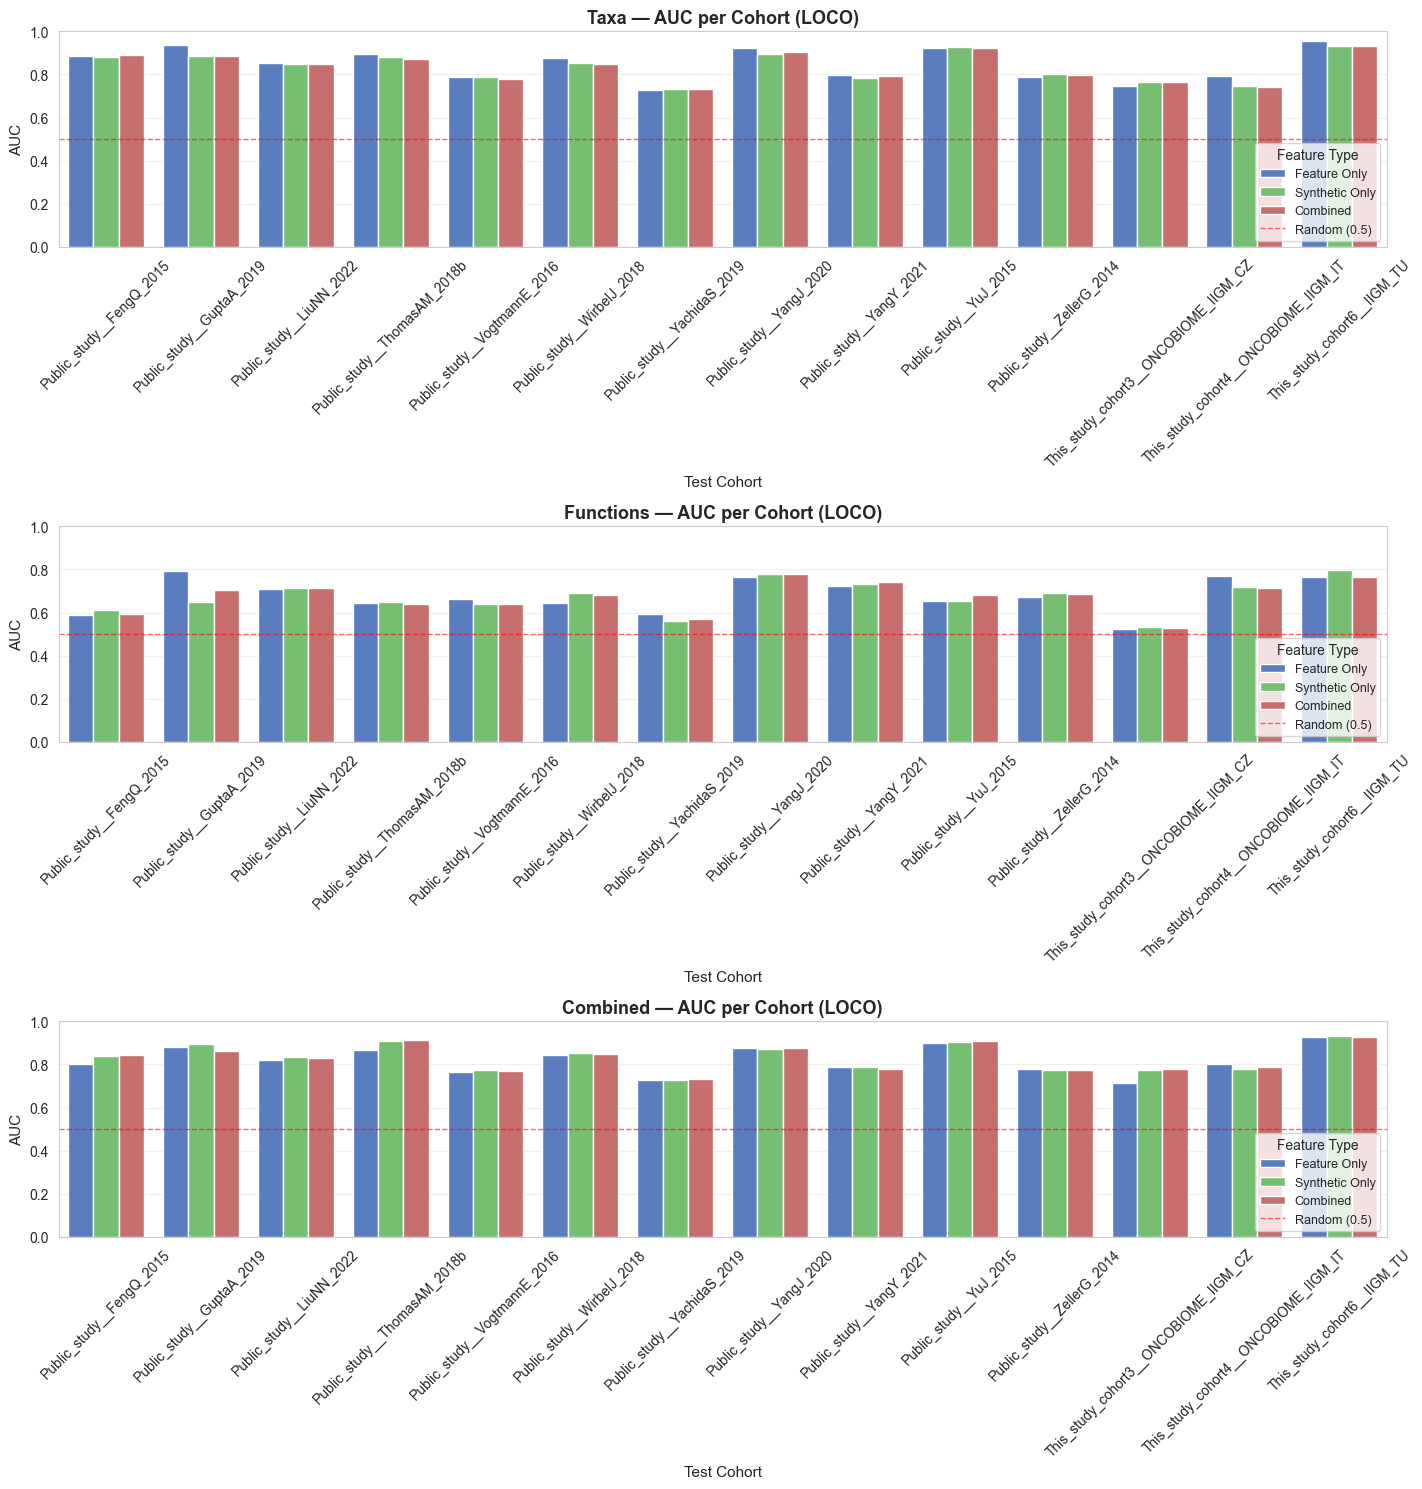

In [6]:
# Per-cohort AUC barplots for Taxa / Functions / Combined
# Each cohort appears once (LOCO), bars grouped by feature configuration.

order = ['Taxa', 'Functions', 'Combined']
palette = {'Feature Only': '#4878CF', 'Synthetic Only': '#6ACC65', 'Combined': '#D65F5F'}
x_label_map = {
    'Taxa': 'All Taxa',
    'Functions': 'All Functions',
    'Combined': 'All Features',
}

fig, axes = plt.subplots(len(results), 1,
                         figsize=(max(14, len(next(iter(results.values())).index) * 0.9), 5 * len(results)))
if len(results) == 1:
    axes = [axes]

for ax, mode in zip(axes, [m for m in order if m in results]):
    df = results[mode]
    fold_data = df.drop(index=[x for x in ['Mean', 'Weighted Mean'] if x in df.index]).copy()

    feature_col = _pick_first_existing(fold_data.columns, COL_SYNONYMS['feature_only'])
    synth_col   = _pick_first_existing(fold_data.columns, COL_SYNONYMS['synthetic_only'])
    comb_col    = _pick_first_existing(fold_data.columns, COL_SYNONYMS['combined'])

    plot_df = fold_data[[feature_col, synth_col, comb_col]].rename(columns={
        feature_col: 'Feature Only',
        synth_col:   'Synthetic Only',
        comb_col:    'Combined',
    }).reset_index()

    if 'Test Cohort' not in plot_df.columns and 'index' in plot_df.columns:
        plot_df = plot_df.rename(columns={'index': 'Test Cohort'})

    long_df = plot_df.melt(id_vars='Test Cohort',
                           value_vars=['Feature Only', 'Synthetic Only', 'Combined'],
                           var_name='Feature Type', value_name='AUC')

    sns.barplot(data=long_df, x='Test Cohort', y='AUC', hue='Feature Type',
                palette=palette, ax=ax, order=sorted(plot_df['Test Cohort']),
                hue_order=['Feature Only', 'Synthetic Only', 'Combined'])

    ax.set_title(f'{mode} — AUC per Cohort (LOCO)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Test Cohort', fontsize=11)
    ax.set_ylabel('AUC', fontsize=11)
    ax.set_ylim(0, 1)
    ax.axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.6, label='Random (0.5)')
    ax.legend(title='Feature Type', loc='lower right', fontsize=9)
    ax.tick_params(axis='x', rotation=45)
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


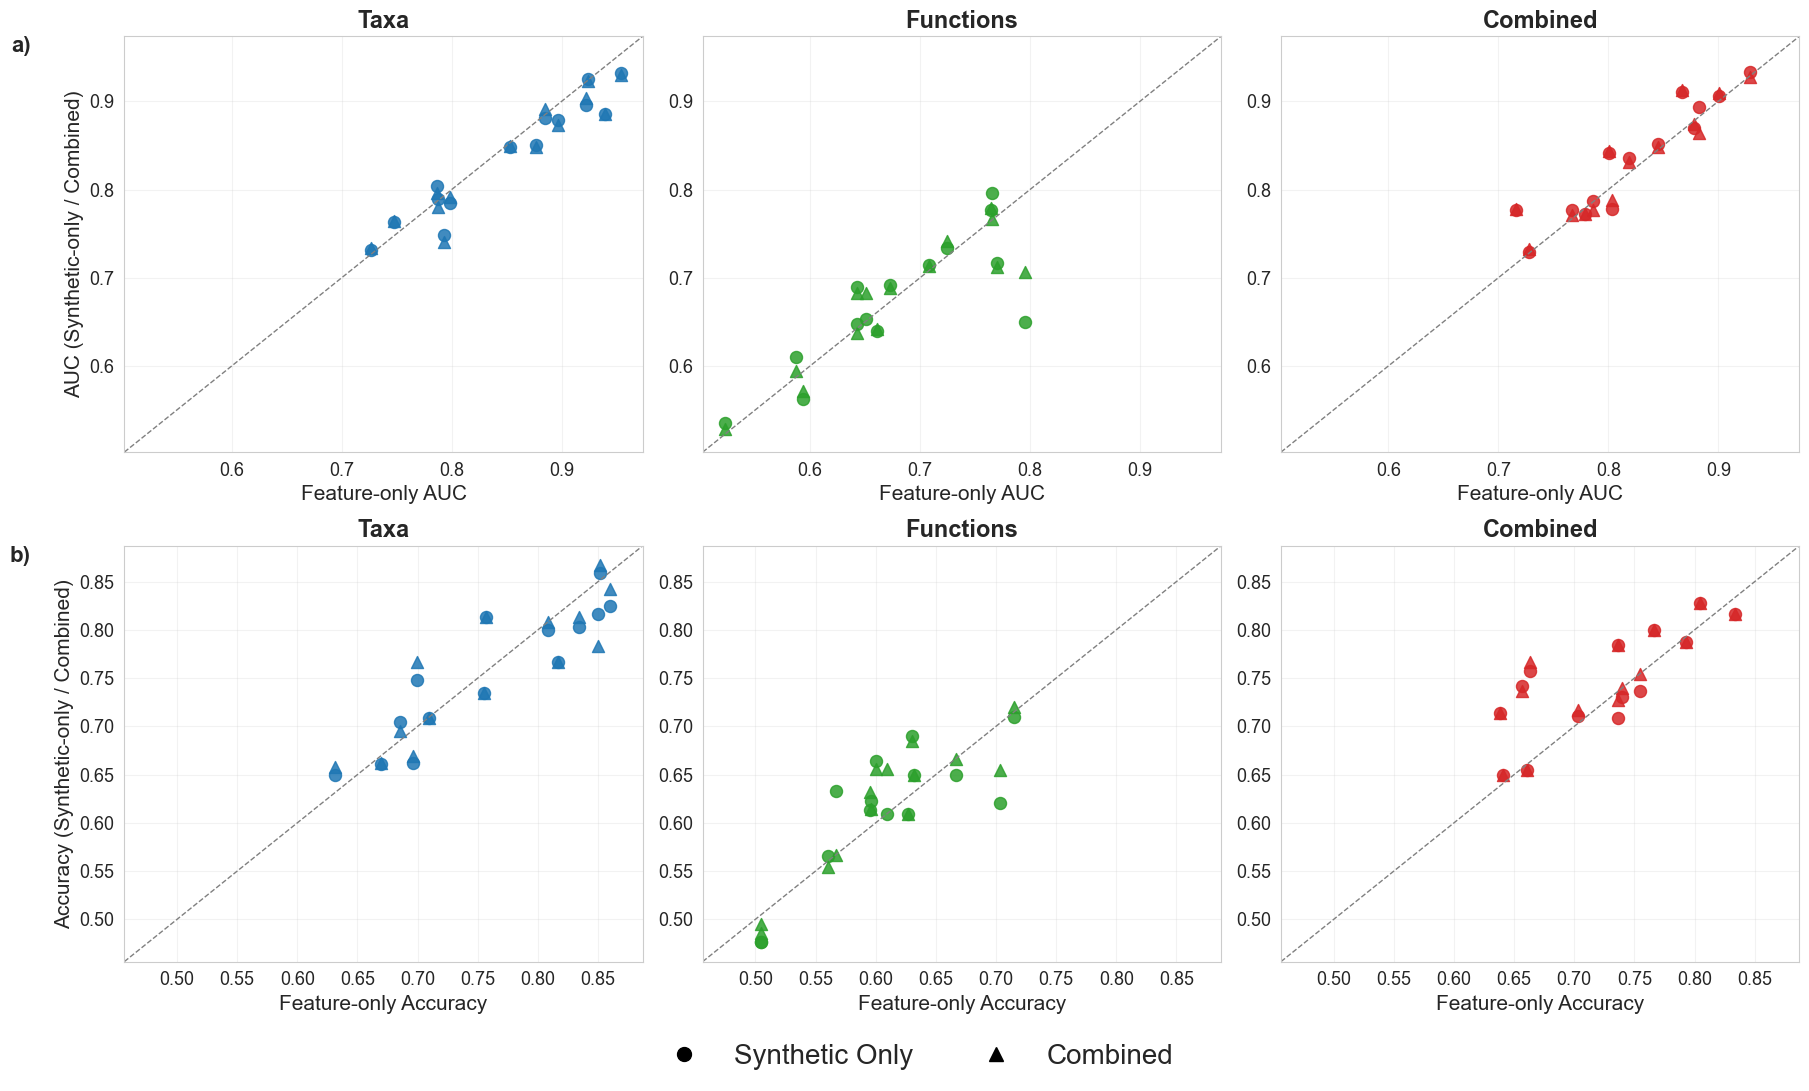

In [7]:
import numpy as np


def _cohort_scatter_data(df, mode_label):
    """Return x=feature-only and y series (synthetic-only, combined) for cohort rows."""
    cohorts_df = df.drop(index=[x for x in ['Mean', 'Weighted Mean'] if x in df.index]).copy()

    feature_col = _pick_first_existing(cohorts_df.columns, COL_SYNONYMS['feature_only'])
    synth_col = _pick_first_existing(cohorts_df.columns, COL_SYNONYMS['synthetic_only'])
    comb_col = _pick_first_existing(cohorts_df.columns, COL_SYNONYMS['combined'])

    if feature_col is None or synth_col is None or comb_col is None:
        raise ValueError(
            f"Missing expected columns for {mode_label}. Found: {cohorts_df.columns.tolist()}\n"
            f"feature_only candidates={COL_SYNONYMS['feature_only']}\n"
            f"synthetic_only candidates={COL_SYNONYMS['synthetic_only']}\n"
            f"combined candidates={COL_SYNONYMS['combined']}"
        )

    plot_df = cohorts_df.reset_index()
    if 'Test Cohort' not in plot_df.columns and 'index' in plot_df.columns:
        plot_df = plot_df.rename(columns={'index': 'Test Cohort'})

    x = plot_df[feature_col].astype(float).to_numpy()
    y_synth = plot_df[synth_col].astype(float).to_numpy()
    y_comb = plot_df[comb_col].astype(float).to_numpy()

    return x, y_synth, y_comb


def _plot_row(ax_row, data_dict, row_title, x_label, y_label):
    order = ['Taxa', 'Functions', 'Combined']

    # Compute global min/max for this metric
    all_vals = []
    mode_data = {}
    for mode in order:
        if mode not in data_dict:
            continue
        x, y_synth, y_comb = _cohort_scatter_data(data_dict[mode], mode)
        mode_data[mode] = (x, y_synth, y_comb)
        all_vals.extend([x, y_synth, y_comb])

    if not all_vals:
        return

    mn = float(np.nanmin([v.min() for v in all_vals]))
    mx = float(np.nanmax([v.max() for v in all_vals]))

    pad = 0.02
    lo = max(0.0, mn - pad)
    hi = min(1.0, mx + pad)

    group_colors = {
        'Taxa': '#1f77b4',
        'Functions': '#2ca02c',
        'Combined': '#d62728',
    }

    markers = {
        'Synthetic Only': 'o',
        'Combined': '^',
    }

    for ax, mode in zip(ax_row, order):
        if mode not in mode_data:
            ax.set_axis_off()
            continue

        x, y_synth, y_comb = mode_data[mode]
        c = group_colors.get(mode, '#1f77b4')

        ax.scatter(x, y_synth, label='Synthetic Only', color=c, alpha=0.85, s=75, marker=markers['Synthetic Only'])
        ax.scatter(x, y_comb, label='Combined', color=c, alpha=0.85, s=75, marker=markers['Combined'])

        ax.plot([lo, hi], [lo, hi], color='gray', linestyle='--', linewidth=1)

        ax.set_title(mode, fontsize=17, fontweight='bold')
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.grid(True, alpha=0.25)

    ax_row[0].set_ylabel(y_label, fontsize=15)
    for ax in ax_row:
        ax.set_xlabel(x_label, fontsize=15)
    for ax in ax_row:
        ax.tick_params(axis='both', labelsize=13)

    return markers


# Load accuracy results (parallel to AUC results)
ACC_RESULT_FILES = {
    'Taxa': 'results_taxa/loco_accuracy_taxa.csv',
    'Functions': 'results_functions/loco_accuracy_functions.csv',
    'Combined': 'results_combined/loco_accuracy_combined.csv',
}

results_acc = {}
for mode, path in ACC_RESULT_FILES.items():
    df = load_loco_results(path)
    if df is not None:
        results_acc[mode] = df


# Build one figure with 2 rows (AUC on top, Accuracy below), 3 columns (Taxa/Functions/Combined)
fig, axes = plt.subplots(2, 3, figsize=(18, 11), sharex=False, sharey=False)

markers = _plot_row(
    axes[0, :],
    results,
    row_title="AUC",
    x_label='Feature-only AUC',
    y_label='AUC (Synthetic-only / Combined)',
)

_plot_row(
    axes[1, :],
    results_acc,
    row_title="Accuracy",
    x_label='Feature-only Accuracy',
    y_label='Accuracy (Synthetic-only / Combined)',
)

# Panel labels: a) top row, b) bottom row (to the left of each row's y-axis)
axes[0, 0].text(-0.18, 1.0, 'a)', transform=axes[0, 0].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')
axes[1, 0].text(-0.18, 1.0, 'b)', transform=axes[1, 0].transAxes, fontsize=16, fontweight='bold', va='top', ha='right')

# Legend: shapes encode Synthetic vs Combined
from matplotlib.lines import Line2D
legend_handles = [
    Line2D([0], [0], marker='o', color='black', linestyle='None', markersize=10, label='Synthetic Only'),
    Line2D([0], [0], marker='^', color='black', linestyle='None', markersize=10, label='Combined'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02), fontsize=20)

#fig.suptitle('Per-cohort performance: Synthetic/Combined vs Feature-only (LOCO)', fontsize=14, fontweight='bold', y=1.02)
fig.tight_layout(rect=[0, 0.04, 1, 0.98])
plt.show()
